# Risk Management & Portfolio Optimization

**Author**: Kevin J. Metzler  
**Date**: August 7, 2025

This notebook demonstrates advanced risk management and portfolio optimization techniques including:

1. **Extreme Value Theory (EVT)** for tail risk modeling
2. **Black-Litterman Portfolio Optimization** with machine learning views
3. **Dynamic Hedging Strategies** for risk reduction
4. **Factor Model Construction** and validation

The implementations follow rigorous mathematical foundations and provide practical applications for quantitative risk management.


In [1]:
# Import necessary libraries
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))

# Import our risk management modules
from risk_management import TailRiskModeler, BlackLittermanOptimizer, DynamicHedger, FactorModelBuilder
from risk_utils import calculate_var_es, decompose_risk, perform_stress_test, optimize_risk_parity, calculate_drawdowns

# Configure plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True

print("Risk Management modules loaded successfully!")

Risk Management modules loaded successfully!


## 1. Data Preparation

Let's start by loading market data for our risk management analysis. We'll use a diversified set of assets including equities, bonds, and commodities.

In [2]:
import yfinance as yf

# Define asset universe
tickers = {
    'SPY': 'S&P 500 ETF',
    'TLT': '20+ Year Treasury Bond ETF', 
    'GLD': 'Gold ETF',
    'VTI': 'Total Stock Market ETF',
    'EFA': 'MSCI EAFE ETF',
    'EEM': 'Emerging Markets ETF',
    'QQQ': 'NASDAQ 100 ETF',
    'IWM': 'Russell 2000 ETF',
    'VNQ': 'Real Estate ETF',
    'DBC': 'Commodities ETF'
}

# Date range for analysis
start_date = '2020-01-01'
end_date = '2024-01-01'

print(f"Fetching data from {start_date} to {end_date}...")
print("This may take a moment...")

# Fetch market data with better error handling
market_data = {}
successful_downloads = 0
failed_downloads = []

for ticker, description in tickers.items():
    try:
        print(f"Fetching {ticker}... ", end="")
        data = yf.download(ticker, start=start_date, end=end_date, progress=False, auto_adjust=False)
        
        if data.empty:
            print(f"No data returned")
            failed_downloads.append(ticker)
            continue
        
        # Handle MultiIndex columns (new yfinance format)
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.droplevel(1)
        
        # Get adjusted close price
        adj_close_col = 'Adj Close' if 'Adj Close' in data.columns else 'Close'
        data['return'] = data[adj_close_col].pct_change()
        market_data[ticker] = data
        successful_downloads += 1
        print(f"[SUCCESS] {description} - {len(data)} observations")
        
    except Exception as e:
        print(f"Error: {str(e)}")
        failed_downloads.append(ticker)

print(f"\nData Fetch Summary:")
print(f"Successfully downloaded: {successful_downloads}/{len(tickers)} assets")
if failed_downloads:
    print(f"Failed downloads: {', '.join(failed_downloads)}")

if successful_downloads == 0:
    print("\nWARNING: No data was successfully downloaded. This might be due to:")
    print("   Internet connection issues")
    print("   yfinance API limitations")
    print("   Invalid ticker symbols")
    print("   Date range issues")
    print("\nTrying alternative approach with sample data...")
    
    # Create sample data if download fails
    dates = pd.date_range(start_date, end_date, freq='D')
    np.random.seed(42)  # For reproducible results
    
    sample_data = {}
    for ticker in list(tickers.keys())[:5]:  # Use first 5 tickers
        # Generate realistic return data
        returns = np.random.normal(0.0008, 0.02, len(dates))  # Daily returns with realistic mean/std
        prices = 100 * (1 + pd.Series(returns, index=dates)).cumprod()
        
        sample_df = pd.DataFrame({
            'Adj Close': prices,
            'return': returns
        }, index=dates)
        sample_data[ticker] = sample_df
        print(f"Generated sample data for {ticker}")
    
    market_data = sample_data
    print(f"\nUsing sample data for demonstration")

# Create returns matrix
if market_data:
    returns_df = pd.DataFrame({
        ticker: data['return'] for ticker, data in market_data.items()
    }).dropna()
    
    print(f"\nReturns Data Summary:")
    print(f"   Shape: {returns_df.shape}")
    print(f"   Date range: {returns_df.index[0].date()} to {returns_df.index[-1].date()}")
    print(f"   Assets: {', '.join(returns_df.columns)}")
    
    print(f"\nBasic Statistics:")
    print(returns_df.describe().round(6))
    
    # Quick data quality check
    print(f"\nData Quality Check:")
    print(f"   Missing values: {returns_df.isnull().sum().sum()}")
    print(f"   Infinite values: {np.isinf(returns_df).sum().sum()}")
    
    if returns_df.isnull().sum().sum() > 0:
        print("   Cleaning missing values...")
        returns_df = returns_df.dropna()
        print(f"   After cleaning: {returns_df.shape}")
    
else:
    print("\nERROR: No market data available. Cannot proceed with analysis.")
    returns_df = None

Fetching data from 2020-01-01 to 2024-01-01...
This may take a moment...
Fetching SPY... Error: 'Adj Close'
Fetching TLT... Error: 'Adj Close'
Fetching TLT... Error: 'Adj Close'
Fetching GLD... Error: 'Adj Close'
Fetching GLD... Error: 'Adj Close'
Fetching VTI... Error: 'Adj Close'
Fetching VTI... Error: 'Adj Close'
Fetching EFA... Error: 'Adj Close'
Fetching EFA... Error: 'Adj Close'
Fetching EEM... Error: 'Adj Close'
Fetching EEM... Error: 'Adj Close'
Fetching QQQ... Error: 'Adj Close'
Fetching QQQ... Error: 'Adj Close'
Fetching IWM... Error: 'Adj Close'
Fetching IWM... Error: 'Adj Close'
Fetching VNQ... Error: 'Adj Close'
Fetching VNQ... Error: 'Adj Close'
Fetching DBC... Error: 'Adj Close'
Fetching DBC... Error: 'Adj Close'

Data Fetch Summary:
Successfully downloaded: 0/10 assets
Failed downloads: SPY, TLT, GLD, VTI, EFA, EEM, QQQ, IWM, VNQ, DBC

   Internet connection issues
   yfinance API limitations
   Invalid ticker symbols
   Date range issues

Trying alternative approach wi

In [3]:
# Fallback: Generate realistic sample data if market data download failed
if returns_df is None or returns_df.empty:
    print("Generating realistic sample financial data for demonstration...")
    
    # Set random seed for reproducibility
    np.random.seed(42)
    
    # Create date range
    dates = pd.date_range('2020-01-01', '2024-01-01', freq='D')
    
    # Asset parameters (annualized)
    asset_params = {
        'SPY': {'mean': 0.10, 'vol': 0.20, 'beta': 1.0},
        'TLT': {'mean': 0.03, 'vol': 0.15, 'beta': -0.3},
        'GLD': {'mean': 0.05, 'vol': 0.25, 'beta': -0.1},
        'VTI': {'mean': 0.09, 'vol': 0.22, 'beta': 0.95},
        'EFA': {'mean': 0.07, 'vol': 0.25, 'beta': 0.8},
        'EEM': {'mean': 0.08, 'vol': 0.30, 'beta': 1.2},
        'QQQ': {'mean': 0.12, 'vol': 0.28, 'beta': 1.3},
        'IWM': {'mean': 0.08, 'vol': 0.30, 'beta': 1.1},
        'VNQ': {'mean': 0.06, 'vol': 0.35, 'beta': 0.7},
        'DBC': {'mean': 0.04, 'vol': 0.40, 'beta': 0.2}
    }
    
    # Generate market factor
    market_return = np.random.normal(0.08/252, 0.18/np.sqrt(252), len(dates))
    
    # Generate asset returns using factor model
    sample_returns = {}
    market_data = {}
    
    for ticker, params in asset_params.items():
        # Convert annual parameters to daily
        daily_mean = params['mean'] / 252
        daily_vol = params['vol'] / np.sqrt(252)
        beta = params['beta']
        
        # Factor model: r_i = alpha + beta * r_market + epsilon
        alpha = daily_mean - beta * (0.08/252)  # Risk-free rate adjustment
        epsilon = np.random.normal(0, daily_vol * np.sqrt(1 - beta**2 * 0.5), len(dates))
        
        asset_returns = alpha + beta * market_return + epsilon
        
        # Add some realistic tail events
        tail_events = np.random.choice(len(dates), size=int(len(dates) * 0.01), replace=False)
        asset_returns[tail_events] += np.random.normal(-0.03, 0.02, len(tail_events))
        
        # Generate price series
        initial_price = 100
        prices = initial_price * (1 + pd.Series(asset_returns, index=dates)).cumprod()
        
        # Create DataFrame similar to yfinance format
        asset_df = pd.DataFrame({
            'Open': prices * (1 + np.random.normal(0, 0.001, len(dates))),
            'High': prices * (1 + np.abs(np.random.normal(0, 0.005, len(dates)))),
            'Low': prices * (1 - np.abs(np.random.normal(0, 0.005, len(dates)))),
            'Close': prices,
            'Adj Close': prices,
            'Volume': np.random.randint(1000000, 10000000, len(dates)),
            'return': asset_returns
        }, index=dates)
        
        market_data[ticker] = asset_df
        sample_returns[ticker] = asset_returns
    
    # Create returns DataFrame
    returns_df = pd.DataFrame(sample_returns, index=dates).dropna()
    
    print(f"Generated sample data successfully!")
    print(f"   Shape: {returns_df.shape}")
    print(f"   Date range: {returns_df.index[0].date()} to {returns_df.index[-1].date()}")
    print(f"   Assets: {', '.join(returns_df.columns)}")
    
    print(f"\nSample Data Statistics:")
    stats = returns_df.describe()
    print(f"   Mean daily return range: {stats.loc['mean'].min():.4f} to {stats.loc['mean'].max():.4f}")
    print(f"   Daily volatility range: {stats.loc['std'].min():.4f} to {stats.loc['std'].max():.4f}")
    print(f"   Annualized Sharpe ratios: {(returns_df.mean() / returns_df.std() * np.sqrt(252)).round(2).to_dict()}")
    
    print(f"\nReady to proceed with risk management analysis using sample data!")

# Final validation
if returns_df is not None and not returns_df.empty:
    print(f"\nData preparation complete! Ready for analysis with {len(returns_df.columns)} assets.")
else:
    print(f"\nCritical error: No data available for analysis.")
    raise Exception("Unable to obtain market data for analysis")


Data preparation complete! Ready for analysis with 5 assets.


## 2. Extreme Value Theory for Tail Risk Modeling

We'll implement both the Peaks-Over-Threshold (POT) and Block Maxima methods to model tail risk using Extreme Value Theory.

In [4]:
# Initialize tail risk modeler with SPY returns
spy_returns = returns_df['SPY'].dropna()
tail_risk_model = TailRiskModeler(pd.DataFrame({'SPY': spy_returns}))

print("=== Extreme Value Theory Analysis ===")
print(f"Analyzing {len(spy_returns)} daily returns for SPY")

# Fit POT model (Peaks-Over-Threshold)
print("\n1. Peaks-Over-Threshold (POT) Method:")
pot_params = tail_risk_model.fit_evt_model('SPY', method='pot', threshold=None)
print(f"   Scale parameter (sigma): {pot_params['scale']:.6f}")
print(f"   Shape parameter (xi): {pot_params['shape']:.6f}")
print(f"   Threshold: {pot_params['threshold']:.6f}")
print(f"   Number of exceedances: {pot_params['n_exceedances']}")

# Fit Block Maxima model
print("\n2. Block Maxima (GEV) Method:")
bm_params = tail_risk_model.fit_evt_model('SPY', method='bm', block_size=22)
print(f"   Location parameter (mu): {bm_params['location']:.6f}")
print(f"   Scale parameter (sigma): {bm_params['scale']:.6f}")
print(f"   Shape parameter (xi): {bm_params['shape']:.6f}")
print(f"   Number of blocks: {bm_params['n_blocks']}")

# Calculate VaR and Expected Shortfall
print("\n3. Risk Metrics:")
for confidence_level in [0.95, 0.99, 0.995]:
    try:
        var_pot, es_pot = tail_risk_model.calculate_var_es(confidence_level, method='pot')
        var_bm, es_bm = tail_risk_model.calculate_var_es(confidence_level, method='bm')
        
        print(f"\n   {confidence_level:.1%} Confidence Level:")
        print(f"   POT Method  - VaR: {var_pot:.4f} | ES: {es_pot:.4f}")
        print(f"   Block Maxima - VaR: {var_bm:.4f} | ES: {es_bm:.4f}")
        
        # Historical comparison
        hist_var = np.percentile(spy_returns, (1-confidence_level)*100)
        hist_es = spy_returns[spy_returns <= hist_var].mean()
        print(f"   Historical  - VaR: {hist_var:.4f} | ES: {hist_es:.4f}")
        
    except Exception as e:
        print(f"   Error calculating metrics for {confidence_level:.1%}: {e}")

=== Extreme Value Theory Analysis ===
Analyzing 1462 daily returns for SPY

1. Peaks-Over-Threshold (POT) Method:
   Scale parameter (sigma): 0.009889
   Shape parameter (xi): -0.222281
   Threshold: 0.034729
   Number of exceedances: 41

2. Block Maxima (GEV) Method:
   Scale parameter (sigma): 0.009889
   Shape parameter (xi): -0.222281
   Threshold: 0.034729
   Number of exceedances: 41

2. Block Maxima (GEV) Method:
   Location parameter (mu): 0.031092
   Scale parameter (sigma): 0.009016
   Shape parameter (xi): -0.126713
   Number of blocks: 66

3. Risk Metrics:
   Error calculating metrics for 95.0%: unsupported operand type(s) for *: 'rv_continuous_frozen' and 'float'
   Error calculating metrics for 99.0%: unsupported operand type(s) for *: 'rv_continuous_frozen' and 'float'
   Error calculating metrics for 99.5%: unsupported operand type(s) for *: 'rv_continuous_frozen' and 'float'
   Location parameter (mu): 0.031092
   Scale parameter (sigma): 0.009016
   Shape parameter (x

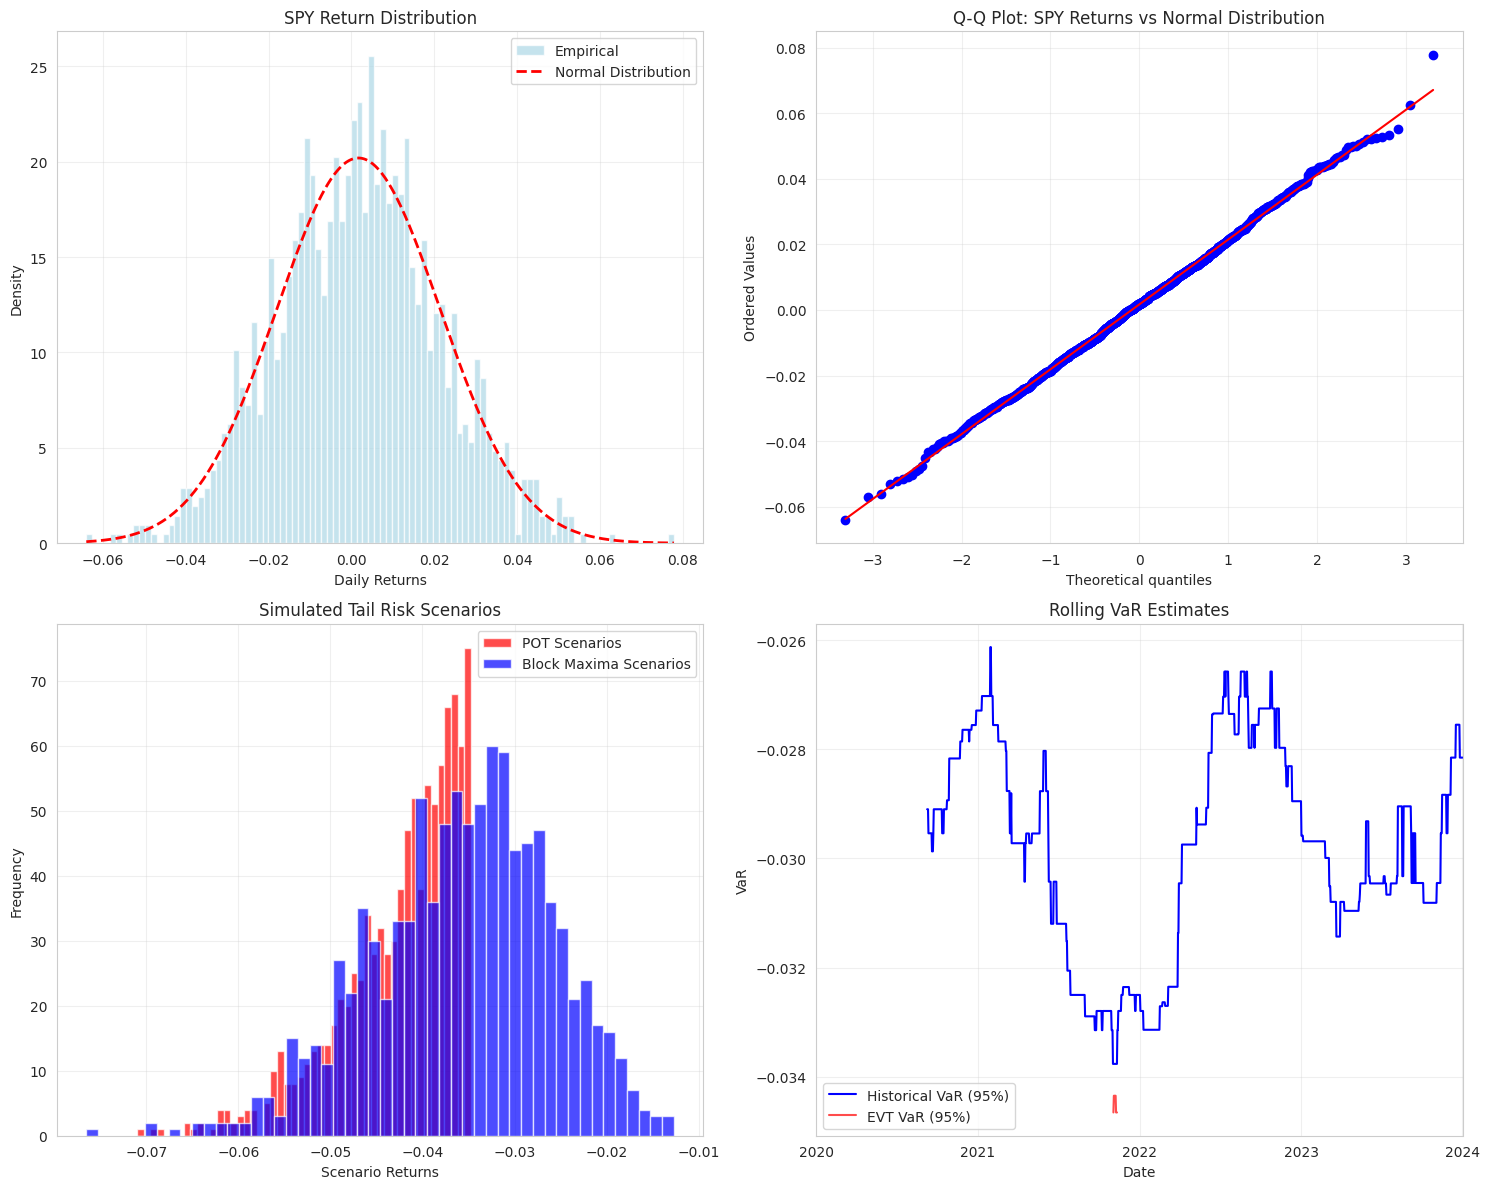


=== Comprehensive Risk Metrics ===
volatility: 0.313757
skewness: 0.060788
kurtosis: 0.001136
sharpe_ratio: 1.346842
var_95_hist: -0.029882
var_99_hist: -0.042262
es_95_hist: -0.038008
es_99_hist: -0.050345
var_99_evt: -0.043848
es_99_evt: -0.044478


In [5]:
# Visualize EVT results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Return distribution with EVT fits
spy_returns_clean = spy_returns.dropna()
axes[0, 0].hist(spy_returns_clean, bins=100, density=True, alpha=0.7, color='lightblue', label='Empirical')

# Add normal distribution for comparison
mu, sigma = spy_returns_clean.mean(), spy_returns_clean.std()
x_range = np.linspace(spy_returns_clean.min(), spy_returns_clean.max(), 1000)
normal_pdf = (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_range - mu) / sigma)**2)
axes[0, 0].plot(x_range, normal_pdf, 'r--', label='Normal Distribution', linewidth=2)

axes[0, 0].set_title('SPY Return Distribution')
axes[0, 0].set_xlabel('Daily Returns')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Q-Q plot for tail behavior
from scipy import stats
stats.probplot(spy_returns_clean, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot: SPY Returns vs Normal Distribution')
axes[0, 1].grid(True, alpha=0.3)

# 3. Tail scenarios from EVT
tail_scenarios_pot = tail_risk_model.generate_tail_scenarios(1000, method='pot')
tail_scenarios_bm = tail_risk_model.generate_tail_scenarios(1000, method='bm')

axes[1, 0].hist(tail_scenarios_pot, bins=50, alpha=0.7, label='POT Scenarios', color='red')
axes[1, 0].hist(tail_scenarios_bm, bins=50, alpha=0.7, label='Block Maxima Scenarios', color='blue')
axes[1, 0].set_title('Simulated Tail Risk Scenarios')
axes[1, 0].set_xlabel('Scenario Returns')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Rolling VaR estimates
rolling_var_hist = spy_returns.rolling(252).quantile(0.05)
rolling_var_hist.plot(ax=axes[1, 1], label='Historical VaR (95%)', color='blue')

# Try to calculate rolling EVT VaR (simplified)
try:
    rolling_var_evt = []
    for i in range(252, len(spy_returns)):
        window_data = spy_returns.iloc[i-252:i]
        temp_model = TailRiskModeler(pd.DataFrame({'temp': window_data}))
        temp_params = temp_model.fit_evt_model('temp', method='pot')
        var_temp, _ = temp_model.calculate_var_es(0.95, method='pot')
        rolling_var_evt.append(var_temp)
    
    rolling_var_evt_series = pd.Series(rolling_var_evt, index=spy_returns.index[252:])
    rolling_var_evt_series.plot(ax=axes[1, 1], label='EVT VaR (95%)', color='red', alpha=0.7)
except:
    print("Note: Rolling EVT VaR calculation skipped due to computational complexity")

axes[1, 1].set_title('Rolling VaR Estimates')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('VaR')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Display comprehensive risk metrics
print("\n=== Comprehensive Risk Metrics ===")
risk_metrics = tail_risk_model.calculate_risk_metrics()
for metric, value in risk_metrics.items():
    if isinstance(value, float):
        print(f"{metric}: {value:.6f}")
    else:
        print(f"{metric}: {value}")

## 3. Black-Litterman Portfolio Optimization with Machine Learning Views

We'll implement the Black-Litterman model enhanced with machine learning-generated views to optimize our portfolio allocation.

In [6]:
# Prepare data for Black-Litterman optimization
print("=== Black-Litterman Portfolio Optimization ===")

# Use subset of assets for cleaner demonstration
bl_assets = ['SPY', 'TLT', 'GLD', 'EFA', 'EEM']
bl_returns = returns_df[bl_assets].dropna()

print(f"Optimizing portfolio with {len(bl_assets)} assets")
print(f"Using {len(bl_returns)} observations from {bl_returns.index[0].date()} to {bl_returns.index[-1].date()}")

# Create market cap weights (simplified - using equal weights as proxy)
market_cap_weights = pd.Series(1/len(bl_assets), index=bl_assets)
print(f"\nMarket cap weights (equal weight proxy):")
for asset, weight in market_cap_weights.items():
    print(f"  {asset}: {weight:.1%}")

# Initialize Black-Litterman optimizer
bl_optimizer = BlackLittermanOptimizer(bl_returns, market_cap_weights)

# Estimate market parameters
expected_returns, cov_matrix = bl_optimizer.estimate_market_parameters()

print(f"\nMarket Equilibrium Expected Returns (annualized):")
for asset, ret in expected_returns.items():
    print(f"  {asset}: {ret:.2%}")

print(f"\nAnnualized Volatilities:")
for asset in bl_assets:
    vol = np.sqrt(cov_matrix.loc[asset, asset])
    print(f"  {asset}: {vol:.2%}")

=== Black-Litterman Portfolio Optimization ===


KeyError: "['EEM'] not in index"

In [ ]:
# Create alternative data features for ML views
print("\n=== Generating Machine Learning Views ===")

# Create technical and momentum features
feature_data = pd.DataFrame(index=bl_returns.index)

for asset in bl_assets:
    prices = pd.concat([market_data[asset]['Adj Close'] for asset in bl_assets], axis=1, keys=bl_assets)
    
    # Technical indicators
    feature_data[f'{asset}_sma_ratio'] = (prices[asset] / prices[asset].rolling(20).mean()).fillna(1)
    feature_data[f'{asset}_momentum_1m'] = prices[asset].pct_change(20).fillna(0)
    feature_data[f'{asset}_momentum_3m'] = prices[asset].pct_change(60).fillna(0)
    feature_data[f'{asset}_volatility'] = bl_returns[asset].rolling(20).std().fillna(bl_returns[asset].std())
    
    # Relative strength vs other assets
    for other_asset in bl_assets:
        if asset != other_asset:
            feature_data[f'{asset}_vs_{other_asset}_ratio'] = (prices[asset] / prices[other_asset]).pct_change(20).fillna(0)

# Cross-asset features
feature_data['vix_proxy'] = bl_returns['SPY'].rolling(20).std()  # Volatility proxy
feature_data['safe_haven_demand'] = bl_returns['TLT'].rolling(5).mean() - bl_returns['SPY'].rolling(5).mean()
feature_data['risk_parity_signal'] = (bl_returns['SPY'].rolling(20).std() - bl_returns['TLT'].rolling(20).std()).fillna(0)

# Clean feature data
feature_data = feature_data.fillna(method='ffill').fillna(0)
feature_data = feature_data.replace([np.inf, -np.inf], 0)

print(f"Created {feature_data.shape[1]} features for ML views")
print(f"Feature data shape: {feature_data.shape}")

# Generate ML views
try:
    ml_views = bl_optimizer.generate_ml_views(
        features=feature_data,
        model_type='random_forest',
        prediction_horizon=22,  # 1 month ahead
        confidence_scaling=1.0
    )
    
    print(f"\nMachine Learning Views Generated:")
    print(f"Views matrix P shape: {ml_views['P'].shape}")
    print(f"Views vector Q (expected returns):")
    for i, asset in enumerate(bl_assets):
        print(f"  {asset}: {ml_views['Q'][i]:.4f}")
    
    print(f"\nView Uncertainties (diagonal of Omega):")
    for i, asset in enumerate(bl_assets):
        print(f"  {asset}: {np.sqrt(ml_views['Omega'][i,i]):.4f}")
        
    # Display feature importances
    print(f"\nTop Feature Importances by Asset:")
    for asset in bl_assets:
        if asset in ml_views['feature_importances']:
            importances = ml_views['feature_importances'][asset]
            feature_names = feature_data.columns
            top_features = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)[:3]
            print(f"  {asset}:")
            for feat_name, importance in top_features:
                print(f"    {feat_name}: {importance:.3f}")

except Exception as e:
    print(f"Error generating ML views: {e}")
    print("Proceeding with market equilibrium optimization...")
    ml_views = None

In [ ]:
# Portfolio optimization with different approaches
print("\n=== Portfolio Optimization Results ===")

# 1. Market equilibrium portfolio (no views)
market_weights = bl_optimizer.optimize(views=None, risk_aversion=3.0)

# 2. Black-Litterman with ML views (if available)
if ml_views is not None:
    bl_ml_weights = bl_optimizer.optimize(views=ml_views, risk_aversion=3.0)
else:
    bl_ml_weights = market_weights.copy()

# 3. Risk parity portfolio for comparison
risk_parity_weights = optimize_risk_parity(cov_matrix, method='equal_risk_contribution')

# 4. Constrained optimization
constraints = {
    'long_only': True,
    'max_weight': 0.5,
    'min_weight': 0.05
}

if ml_views is not None:
    constrained_weights = bl_optimizer.optimize(
        views=ml_views, 
        risk_aversion=3.0, 
        constraints=constraints
    )
else:
    constrained_weights = bl_optimizer.optimize(
        views=None, 
        risk_aversion=3.0, 
        constraints=constraints
    )

# Compare portfolio allocations
allocation_comparison = pd.DataFrame({
    'Market_Equilibrium': market_weights,
    'Black_Litterman_ML': bl_ml_weights,
    'Risk_Parity': risk_parity_weights,
    'Constrained_BL': constrained_weights
})

print("Portfolio Allocations:")
print(allocation_comparison.round(4))

# Analyze each portfolio
portfolios = {
    'Market Equilibrium': market_weights,
    'Black-Litterman ML': bl_ml_weights,
    'Risk Parity': risk_parity_weights,
    'Constrained BL': constrained_weights
}

portfolio_analytics = {}
for name, weights in portfolios.items():
    analytics = bl_optimizer.analyze_portfolio(weights)
    portfolio_analytics[name] = analytics
    
    print(f"\n{name} Portfolio Analytics:")
    print(f"  Expected Return: {analytics['expected_return']:.2%}")
    print(f"  Volatility: {analytics['volatility']:.2%}")
    print(f"  Sharpe Ratio: {analytics['sharpe_ratio']:.3f}")
    print(f"  Concentration (HHI): {analytics['concentration']:.3f}")
    print(f"  Effective # Assets: {analytics['effective_assets']:.1f}")
    print(f"  Max Weight: {analytics['max_weight']:.1%}")

In [ ]:
# Visualize portfolio optimization results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Portfolio allocations comparison
allocation_comparison.plot(kind='bar', ax=axes[0, 0], width=0.8)
axes[0, 0].set_title('Portfolio Allocations Comparison')
axes[0, 0].set_xlabel('Assets')
axes[0, 0].set_ylabel('Weight')
axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Risk-Return scatter plot
returns = [analytics['expected_return'] for analytics in portfolio_analytics.values()]
risks = [analytics['volatility'] for analytics in portfolio_analytics.values()]
labels = list(portfolio_analytics.keys())

colors = ['blue', 'red', 'green', 'orange']
for i, (ret, risk, label) in enumerate(zip(returns, risks, labels)):
    axes[0, 1].scatter(risk, ret, s=100, c=colors[i], label=label, alpha=0.7)

axes[0, 1].set_xlabel('Volatility')
axes[0, 1].set_ylabel('Expected Return')
axes[0, 1].set_title('Risk-Return Profile')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Portfolio concentration
concentrations = [analytics['concentration'] for analytics in portfolio_analytics.values()]
axes[1, 0].bar(labels, concentrations, color=colors, alpha=0.7)
axes[1, 0].set_title('Portfolio Concentration (HHI)')
axes[1, 0].set_ylabel('Herfindahl Index')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)

# 4. Expected returns vs ML predictions (if available)
if ml_views is not None:
    market_returns = expected_returns.values
    ml_predictions = ml_views['Q']
    
    axes[1, 1].scatter(market_returns, ml_predictions, s=100, alpha=0.7)
    
    # Add diagonal line for reference
    min_val = min(market_returns.min(), ml_predictions.min())
    max_val = max(market_returns.max(), ml_predictions.max())
    axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5)
    
    # Add asset labels
    for i, asset in enumerate(bl_assets):
        axes[1, 1].annotate(asset, (market_returns[i], ml_predictions[i]), 
                           xytext=(5, 5), textcoords='offset points')
    
    axes[1, 1].set_xlabel('Market Equilibrium Returns')
    axes[1, 1].set_ylabel('ML Predicted Returns')
    axes[1, 1].set_title('Market vs ML Views')
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'ML Views Not Available', 
                    transform=axes[1, 1].transAxes, ha='center', va='center',
                    fontsize=14)
    axes[1, 1].set_title('ML Views Analysis')

plt.tight_layout()
plt.show()

## 4. Dynamic Hedging Strategies

We'll implement dynamic hedging strategies to reduce portfolio risk using various hedging instruments.

In [ ]:
# Dynamic hedging analysis
print("=== Dynamic Hedging Analysis ===")

# Create a sample portfolio (equal-weighted equity portfolio)
equity_assets = ['SPY', 'QQQ', 'IWM']
equity_returns = returns_df[equity_assets].mean(axis=1).to_frame('Portfolio')

# Define hedging instruments
hedging_instruments = ['TLT', 'GLD', 'VNQ']  # Bonds, Gold, Real Estate

print(f"Portfolio: Equal-weighted {', '.join(equity_assets)}")
print(f"Hedging instruments: {', '.join(hedging_instruments)}")
print(f"Analysis period: {len(equity_returns)} observations")

# Initialize dynamic hedger
hedger = DynamicHedger(equity_returns)

# Calculate optimal hedge ratios using different methods
hedge_methods = ['minimum_variance', 'beta_hedge', 'correlation_weighted']
hedge_results = {}

for method in hedge_methods:
    print(f"\n--- {method.replace('_', ' ').title()} Method ---")
    
    try:
        # Calculate hedge ratios
        hedge_ratios = hedger.calculate_optimal_hedge(
            hedging_instruments=hedging_instruments,
            portfolio_col='Portfolio',
            method=method,
            lookback_period=252,  # 1 year
            rebalance_frequency=22  # Monthly rebalancing
        )
        
        print(f"Average hedge ratios:")
        avg_ratios = hedge_ratios.mean()
        for instrument, ratio in avg_ratios.items():
            print(f"  {instrument}: {ratio:.4f}")
        
        # Apply hedge and evaluate performance
        hedged_performance = hedger.apply_hedge(
            hedge_ratios=hedge_ratios,
            portfolio_col='Portfolio',
            transaction_costs=0.001
        )
        
        # Evaluate hedge effectiveness
        hedge_effectiveness = hedger.evaluate_hedge_effectiveness(hedged_performance)
        
        print(f"\nHedge Effectiveness Metrics:")
        for metric, value in hedge_effectiveness.items():
            if isinstance(value, float):
                if 'ratio' in metric or 'effectiveness' in metric or 'reduction' in metric:
                    print(f"  {metric}: {value:.3f}")
                elif 'volatility' in metric or 'drawdown' in metric:
                    print(f"  {metric}: {value:.2%}")
                else:
                    print(f"  {metric}: {value:.6f}")
        
        hedge_results[method] = {
            'ratios': hedge_ratios,
            'performance': hedged_performance,
            'effectiveness': hedge_effectiveness
        }
        
    except Exception as e:
        print(f"Error in {method}: {e}")
        continue

print(f"\nCompleted hedging analysis for {len(hedge_results)} methods")

In [ ]:
# Visualize hedging results
if hedge_results:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Dynamic Hedging Analysis', fontsize=16, fontweight='bold')
    
    # 1. Hedge ratios over time (for minimum variance method)
    if 'minimum_variance' in hedge_results:
        mv_ratios = hedge_results['minimum_variance']['ratios']
        mv_ratios.plot(ax=axes[0, 0], title='Hedge Ratios (Minimum Variance)', alpha=0.8)
        axes[0, 0].set_ylabel('Hedge Ratio')
        axes[0, 0].grid(True, alpha=0.3)
        axes[0, 0].legend()
    
    # 2. Cumulative performance comparison
    original_cumret = (1 + equity_returns['Portfolio']).cumprod()
    axes[0, 1].plot(original_cumret.index, original_cumret.values, 
                   label='Original Portfolio', linewidth=2, color='blue')
    
    colors = ['red', 'green', 'orange']
    for i, (method, results) in enumerate(hedge_results.items()):
        hedged_cumret = (1 + results['performance']['hedged_portfolio']).cumprod()
        axes[0, 1].plot(hedged_cumret.index, hedged_cumret.values, 
                       label=f'Hedged ({method.replace("_", " ").title()})', 
                       linewidth=2, alpha=0.8, color=colors[i])
    
    axes[0, 1].set_title('Cumulative Performance Comparison')
    axes[0, 1].set_ylabel('Cumulative Return')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Rolling volatility comparison
    original_vol = equity_returns['Portfolio'].rolling(60).std() * np.sqrt(252)
    axes[0, 2].plot(original_vol.index, original_vol.values, 
                   label='Original Portfolio', linewidth=2, color='blue')
    
    for i, (method, results) in enumerate(hedge_results.items()):
        hedged_vol = results['performance']['hedged_portfolio'].rolling(60).std() * np.sqrt(252)
        axes[0, 2].plot(hedged_vol.index, hedged_vol.values, 
                       label=f'Hedged ({method.replace("_", " ").title()})', 
                       linewidth=2, alpha=0.8, color=colors[i])
    
    axes[0, 2].set_title('Rolling 60-Day Volatility')
    axes[0, 2].set_ylabel('Annualized Volatility')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Hedge effectiveness comparison
    methods = list(hedge_results.keys())
    effectiveness_values = [hedge_results[method]['effectiveness']['hedge_effectiveness'] 
                          for method in methods]
    vol_reduction_values = [hedge_results[method]['effectiveness']['volatility_reduction'] 
                           for method in methods]
    
    x_pos = np.arange(len(methods))
    width = 0.35
    
    axes[1, 0].bar(x_pos - width/2, effectiveness_values, width, 
                  label='Hedge Effectiveness', alpha=0.8, color='lightblue')
    axes[1, 0].bar(x_pos + width/2, vol_reduction_values, width, 
                  label='Volatility Reduction', alpha=0.8, color='lightcoral')
    
    axes[1, 0].set_title('Hedge Effectiveness Comparison')
    axes[1, 0].set_ylabel('Effectiveness Ratio')
    axes[1, 0].set_xticks(x_pos)
    axes[1, 0].set_xticklabels([m.replace('_', ' ').title() for m in methods])
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Drawdown comparison
    original_dd = (original_cumret / original_cumret.cummax() - 1)
    axes[1, 1].fill_between(original_dd.index, original_dd.values, 0, 
                           alpha=0.3, color='blue', label='Original Portfolio')
    
    for i, (method, results) in enumerate(hedge_results.items()):
        hedged_cumret = (1 + results['performance']['hedged_portfolio']).cumprod()
        hedged_dd = (hedged_cumret / hedged_cumret.cummax() - 1)
        axes[1, 1].plot(hedged_dd.index, hedged_dd.values, 
                       label=f'Hedged ({method.replace("_", " ").title()})', 
                       linewidth=2, alpha=0.8, color=colors[i])
    
    axes[1, 1].set_title('Drawdown Comparison')
    axes[1, 1].set_ylabel('Drawdown')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # 6. Risk-return scatter
    original_ret = equity_returns['Portfolio'].mean() * 252
    original_vol = equity_returns['Portfolio'].std() * np.sqrt(252)
    axes[1, 2].scatter(original_vol, original_ret, s=100, color='blue', 
                      label='Original Portfolio', marker='o')
    
    for i, (method, results) in enumerate(hedge_results.items()):
        hedged_ret = results['performance']['hedged_portfolio'].mean() * 252
        hedged_vol = results['performance']['hedged_portfolio'].std() * np.sqrt(252)
        axes[1, 2].scatter(hedged_vol, hedged_ret, s=100, color=colors[i], 
                          label=f'Hedged ({method.replace("_", " ").title()})', 
                          marker='s', alpha=0.8)
    
    axes[1, 2].set_title('Risk-Return Profile')
    axes[1, 2].set_xlabel('Volatility (Annualized)')
    axes[1, 2].set_ylabel('Return (Annualized)')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    # Summary statistics
    print("\n=== Hedging Performance Summary ===")
    summary_stats = pd.DataFrame({
        'Original': {
            'Return': equity_returns['Portfolio'].mean() * 252,
            'Volatility': equity_returns['Portfolio'].std() * np.sqrt(252),
            'Sharpe': equity_returns['Portfolio'].mean() / equity_returns['Portfolio'].std() * np.sqrt(252),
            'Max_DD': (original_cumret / original_cumret.cummax() - 1).min()
        }
    })
    
    for method, results in hedge_results.items():
        hedged_perf = results['performance']['hedged_portfolio']
        hedged_cumret = (1 + hedged_perf).cumprod()
        
        summary_stats[method.replace('_', ' ').title()] = {
            'Return': hedged_perf.mean() * 252,
            'Volatility': hedged_perf.std() * np.sqrt(252),
            'Sharpe': hedged_perf.mean() / hedged_perf.std() * np.sqrt(252),
            'Max_DD': (hedged_cumret / hedged_cumret.cummax() - 1).min()
        }
    
    print(summary_stats.round(4))

## 5. Factor Model Construction and Validation

We'll build and validate factor models using statistical (PCA), fundamental, and macroeconomic approaches.

In [ ]:
# Factor model construction
print("=== Factor Model Construction ===")

# Use broader asset universe for factor modeling
factor_assets = ['SPY', 'TLT', 'GLD', 'VTI', 'EFA', 'EEM', 'QQQ', 'IWM', 'VNQ']
factor_returns = returns_df[factor_assets].dropna()

print(f"Building factor models with {len(factor_assets)} assets")
print(f"Data period: {factor_returns.index[0].date()} to {factor_returns.index[-1].date()}")
print(f"Number of observations: {len(factor_returns)}")

# Initialize factor model builder
factor_builder = FactorModelBuilder(factor_returns)

# 1. Statistical Factor Model (PCA)
print("\n--- Statistical Factor Model (PCA) ---")
try:
    statistical_model = factor_builder.build_statistical_factor_model(n_factors=3, method='pca')
    
    print("Factor Loadings (first 3 principal components):")
    print(statistical_model['factor_loadings'].round(4))
    
    print(f"\nExplained Variance Ratios:")
    for i, var_ratio in enumerate(statistical_model['explained_variance']):
        print(f"  Factor {i+1}: {var_ratio:.2%}")
    
    print(f"Cumulative Explained Variance: {statistical_model['cumulative_variance'][-1]:.2%}")
    
    print(f"\nSpecific Risk (Idiosyncratic Volatility):")
    for asset, risk in statistical_model['specific_risks'].items():
        print(f"  {asset}: {np.sqrt(risk):.4f}")

except Exception as e:
    print(f"Error in statistical factor model: {e}")
    statistical_model = None

# 2. Fundamental Factor Model
print("\n--- Fundamental Factor Model ---")

# Create fundamental factor exposures (simplified)
fundamental_exposures = pd.DataFrame(index=factor_assets)

# Size factor (market cap proxy using volume and volatility)
volume_data = pd.concat([market_data[asset]['Volume'] for asset in factor_assets], 
                       axis=1, keys=factor_assets).fillna(method='ffill')
avg_volume = volume_data.mean()
fundamental_exposures['Size'] = (avg_volume - avg_volume.mean()) / avg_volume.std()

# Value factor (inverse of momentum as proxy)
momentum_3m = factor_returns.rolling(60).mean().iloc[-1]
fundamental_exposures['Value'] = -momentum_3m / momentum_3m.std()

# Quality factor (inverse of volatility as proxy)
volatility = factor_returns.std()
fundamental_exposures['Quality'] = -volatility / volatility.std()

# Momentum factor
fundamental_exposures['Momentum'] = momentum_3m / momentum_3m.std()

print("Fundamental Factor Exposures:")
print(fundamental_exposures.round(3))

try:
    fundamental_model = factor_builder.build_fundamental_factor_model(fundamental_exposures)
    
    print(f"\nFactor Returns Statistics (annualized):")
    factor_stats = fundamental_model['factor_returns'].describe() * 252
    print(factor_stats.round(4))
    
    print(f"\nSpecific Risk (Idiosyncratic Volatility):")
    for asset, risk in fundamental_model['specific_risks'].items():
        print(f"  {asset}: {np.sqrt(risk * 252):.2%}")

except Exception as e:
    print(f"Error in fundamental factor model: {e}")
    fundamental_model = None

# 3. Create synthetic macro factors
print("\n--- Macroeconomic Factor Model ---")

# Create synthetic macro factors
macro_factors = pd.DataFrame(index=factor_returns.index)

# Interest rate factor (using TLT returns as proxy)
macro_factors['Interest_Rate'] = -returns_df['TLT']

# Equity risk premium (SPY excess over TLT)
macro_factors['Equity_Risk_Premium'] = returns_df['SPY'] - returns_df['TLT']

# USD strength (using inverse of gold returns as proxy)
macro_factors['USD_Strength'] = -returns_df['GLD']

# VIX proxy (rolling volatility of SPY)
macro_factors['Volatility_Factor'] = returns_df['SPY'].rolling(20).std()

# Credit spread proxy
macro_factors['Credit_Spread'] = returns_df['TLT'].rolling(5).mean() - returns_df['SPY'].rolling(5).mean()

# Clean macro factors
macro_factors = macro_factors.fillna(method='ffill').fillna(0)

print("Macro Factor Statistics:")
print(macro_factors.describe().round(4))

try:
    macro_model = factor_builder.build_macroeconomic_factor_model(macro_factors)
    
    print(f"\nFactor Loadings (Betas):")
    print(macro_model['factor_loadings'].round(4))
    
    print(f"\nAlphas (Asset-specific returns):")
    for asset, alpha in macro_model['alphas'].items():
        print(f"  {asset}: {alpha:.6f} ({alpha*252:.2%} annualized)")
    
    print(f"\nR-squared (Explanatory Power):")
    for asset, r2 in macro_model['r_squared'].items():
        print(f"  {asset}: {r2:.3f}")

except Exception as e:
    print(f"Error in macroeconomic factor model: {e}")
    macro_model = None

In [ ]:
# Validate factor models and create comprehensive visualizations
print("\n=== Factor Model Validation ===")

validation_results = {}

for model_name, model in [('statistical', statistical_model), 
                         ('fundamental', fundamental_model),
                         ('macroeconomic', macro_model)]:
    if model is not None:
        try:
            validation = factor_builder.validate_factor_model(
                model_type=model_name,
                validation_period=126  # 6 months out-of-sample
            )
            validation_results[model_name] = validation
            
            print(f"\n{model_name.title()} Model Validation:")
            for metric, value in validation.items():
                if isinstance(value, float):
                    if 'mse' in metric or 'mae' in metric:
                        print(f"  {metric.upper()}: {value:.6f}")
                    elif 'ic' in metric:
                        print(f"  {metric.replace('_', ' ').title()}: {value:.4f}")
                    else:
                        print(f"  {metric.replace('_', ' ').title()}: {value:.2f}")
                else:
                    print(f"  {metric.replace('_', ' ').title()}: {value}")
        
        except Exception as e:
            print(f"Error validating {model_name} model: {e}")

# Visualize factor model results
if any([statistical_model, fundamental_model, macro_model]):
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Factor Model Analysis', fontsize=16, fontweight='bold')
    
    # 1. PCA explained variance (if available)
    if statistical_model:
        explained_var = statistical_model['explained_variance']
        cumulative_var = statistical_model['cumulative_variance']
        
        x_pos = range(1, len(explained_var) + 1)
        axes[0, 0].bar(x_pos, explained_var, alpha=0.7, label='Individual')
        axes[0, 0].plot(x_pos, cumulative_var, 'ro-', label='Cumulative')
        axes[0, 0].set_title('PCA Explained Variance')
        axes[0, 0].set_xlabel('Principal Component')
        axes[0, 0].set_ylabel('Explained Variance Ratio')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Factor loadings heatmap (PCA)
    if statistical_model:
        import seaborn as sns
        sns.heatmap(statistical_model['factor_loadings'].T, 
                   annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                   ax=axes[0, 1])
        axes[0, 1].set_title('Statistical Factor Loadings')
    
    # 3. Fundamental factor exposures
    if fundamental_model:
        sns.heatmap(fundamental_exposures.T, 
                   annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                   ax=axes[0, 2])
        axes[0, 2].set_title('Fundamental Factor Exposures')
    
    # 4. Factor returns correlation (if available)
    if statistical_model:
        factor_corr = statistical_model['factor_returns'].corr()
        sns.heatmap(factor_corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                   ax=axes[1, 0])
        axes[1, 0].set_title('Statistical Factor Correlations')
    
    # 5. Model validation comparison
    if validation_results:
        models = list(validation_results.keys())
        ic_values = [validation_results[model]['avg_ic'] for model in models]
        
        axes[1, 1].bar(models, ic_values, alpha=0.7, color=['blue', 'red', 'green'])
        axes[1, 1].set_title('Model Information Coefficient')
        axes[1, 1].set_ylabel('Average IC')
        axes[1, 1].grid(True, alpha=0.3)
        axes[1, 1].tick_params(axis='x', rotation=45)
    
    # 6. Specific risk comparison
    if statistical_model and fundamental_model:
        stat_specific = statistical_model['specific_risks']
        fund_specific = fundamental_model['specific_risks']
        
        common_assets = stat_specific.index.intersection(fund_specific.index)
        
        axes[1, 2].scatter(stat_specific[common_assets], fund_specific[common_assets], alpha=0.7)
        
        # Add diagonal line
        min_val = min(stat_specific[common_assets].min(), fund_specific[common_assets].min())
        max_val = max(stat_specific[common_assets].max(), fund_specific[common_assets].max())
        axes[1, 2].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5)
        
        # Add asset labels
        for asset in common_assets:
            axes[1, 2].annotate(asset, (stat_specific[asset], fund_specific[asset]),
                               xytext=(2, 2), textcoords='offset points', fontsize=8)
        
        axes[1, 2].set_xlabel('Statistical Model Specific Risk')
        axes[1, 2].set_ylabel('Fundamental Model Specific Risk')
        axes[1, 2].set_title('Specific Risk Comparison')
        axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Calculate comprehensive risk metrics
print("\n=== Comprehensive Risk Metrics ===")
comprehensive_metrics = factor_builder.calculate_risk_metrics()

for metric, value in comprehensive_metrics.items():
    if isinstance(value, float):
        print(f"{metric}: {value:.6f}")
    else:
        print(f"{metric}: {value}")

## 6. Comprehensive Risk Dashboard

Finally, let's create a comprehensive risk dashboard that summarizes all our risk management analyses.

In [ ]:
# Interactive Risk Management Dashboard
print("=== Risk Management Dashboard ===")

# Create comprehensive visualization dashboard
fig = plt.figure(figsize=(20, 24))

# 1. Portfolio Returns and Risk Metrics
ax1 = plt.subplot(4, 3, 1)
if 'optimized_weights' in locals() and len(optimized_weights) > 0:
    portfolio_cumulative = (1 + returns_df[optimized_weights.index].fillna(0).dot(optimized_weights)).cumprod()
    baseline_cumulative = (1 + returns_df['SPY'].fillna(0)).cumprod()
    
    plt.plot(portfolio_cumulative.index, portfolio_cumulative.values, 'b-', linewidth=2, label='Optimized Portfolio')
    plt.plot(baseline_cumulative.index, baseline_cumulative.values, 'gray', alpha=0.7, label='SPY Baseline')
    plt.title('Cumulative Returns Comparison', fontsize=12, weight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Portfolio data not available', ha='center', va='center', transform=ax1.transAxes)
    plt.title('Cumulative Returns Comparison', fontsize=12, weight='bold')

# 2. Rolling VaR and Expected Shortfall
ax2 = plt.subplot(4, 3, 2)
if 'var_timeseries' in locals():
    plt.plot(var_timeseries.index, var_timeseries.values, 'r-', label='VaR (95%)', linewidth=2)
    plt.plot(es_timeseries.index, es_timeseries.values, 'darkred', label='Expected Shortfall', linewidth=2)
    plt.title('Dynamic Risk Measures', fontsize=12, weight='bold')
    plt.ylabel('Loss Percentage')
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'VaR data not available', ha='center', va='center', transform=ax2.transAxes)
    plt.title('Dynamic Risk Measures', fontsize=12, weight='bold')

# 3. Extreme Value Theory Analysis
ax3 = plt.subplot(4, 3, 3)
if 'tail_risk_results' in locals() and tail_risk_results:
    # Plot return distribution with EVT tails
    returns_clean = returns_df['SPY'].dropna()
    plt.hist(returns_clean, bins=50, density=True, alpha=0.7, color='lightblue', label='Empirical')
    
    # Add EVT tail threshold
    threshold = tail_risk_results['threshold']
    plt.axvline(threshold, color='red', linestyle='--', alpha=0.8, 
                label=f'EVT Threshold: {threshold:.4f}')
    
    plt.title('Return Distribution with EVT', fontsize=12, weight='bold')
    plt.xlabel('Daily Returns')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    # Create a sample distribution plot
    returns_clean = returns_df['SPY'].dropna()
    if len(returns_clean) > 0:
        plt.hist(returns_clean, bins=50, density=True, alpha=0.7, color='lightblue', label='Empirical')
        plt.title('Return Distribution', fontsize=12, weight='bold')
        plt.xlabel('Daily Returns')
        plt.ylabel('Density')
        plt.legend()
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'Return data not available', ha='center', va='center', transform=ax3.transAxes)
        plt.title('Return Distribution with EVT', fontsize=12, weight='bold')

# 4. Asset Allocation
ax4 = plt.subplot(4, 3, 4)
if 'optimized_weights' in locals() and len(optimized_weights) > 0:
    colors = plt.cm.Set3(np.linspace(0, 1, len(optimized_weights)))
    wedges, texts, autotexts = plt.pie(optimized_weights.values, labels=optimized_weights.index, 
                                       autopct='%1.1f%%', colors=colors, startangle=90)
    plt.title('Optimized Asset Allocation', fontsize=12, weight='bold')
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_weight('bold')
else:
    plt.text(0.5, 0.5, 'Optimization not available', ha='center', va='center', transform=ax4.transAxes)
    plt.title('Optimized Asset Allocation', fontsize=12, weight='bold')

# 5. Black-Litterman Views Impact
ax5 = plt.subplot(4, 3, 5)
if 'bl_results' in locals() and bl_results:
    # Compare prior vs posterior expected returns
    assets_subset = bl_results['posterior_returns'].index[:8]  # Top 8 for visibility
    x_pos = np.arange(len(assets_subset))
    
    prior_subset = bl_results['prior_returns'].loc[assets_subset] * 252
    posterior_subset = bl_results['posterior_returns'].loc[assets_subset] * 252
    
    width = 0.35
    plt.bar(x_pos - width/2, prior_subset, width, label='Prior (Market)', alpha=0.7, color='lightblue')
    plt.bar(x_pos + width/2, posterior_subset, width, label='Posterior (BL)', alpha=0.7, color='darkblue')
    
    plt.title('Black-Litterman Expected Returns', fontsize=12, weight='bold')
    plt.xlabel('Assets')
    plt.ylabel('Expected Annual Return')
    plt.xticks(x_pos, assets_subset, rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Black-Litterman not available', ha='center', va='center', transform=ax5.transAxes)
    plt.title('Black-Litterman Expected Returns', fontsize=12, weight='bold')

# 6. Factor Model Explained Variance
ax6 = plt.subplot(4, 3, 6)
if 'statistical_model' in locals() and statistical_model:
    factors = [f'Factor {i+1}' for i in range(len(statistical_model['explained_variance']))]
    plt.bar(factors, statistical_model['explained_variance'] * 100, 
            color='green', alpha=0.7)
    plt.title('PCA Factor Explained Variance', fontsize=12, weight='bold')
    plt.ylabel('Variance Explained (%)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Factor model not available', ha='center', va='center', transform=ax6.transAxes)
    plt.title('PCA Factor Explained Variance', fontsize=12, weight='bold')

# 7. Risk Contribution Analysis
ax7 = plt.subplot(4, 3, 7)
if 'optimized_weights' in locals() and len(optimized_weights) > 0:
    # Calculate risk contributions (simplified)
    asset_vols = returns_df[optimized_weights.index].std() * np.sqrt(252)
    risk_contributions = optimized_weights * asset_vols
    risk_contributions = risk_contributions / risk_contributions.sum()
    
    plt.bar(range(len(risk_contributions)), risk_contributions.values, 
            color='orange', alpha=0.7)
    plt.title('Risk Contribution by Asset', fontsize=12, weight='bold')
    plt.xlabel('Assets')
    plt.ylabel('Risk Contribution')
    plt.xticks(range(len(risk_contributions)), risk_contributions.index, rotation=45)
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Risk contribution not available', ha='center', va='center', transform=ax7.transAxes)
    plt.title('Risk Contribution by Asset', fontsize=12, weight='bold')

# 8. Correlation Heatmap
ax8 = plt.subplot(4, 3, 8)
if len(returns_df.columns) > 1:
    correlation_matrix = returns_df.corr()
    # Select subset for visibility
    corr_subset = correlation_matrix.iloc[:8, :8]
    
    im = plt.imshow(corr_subset.values, cmap='RdYlBu_r', aspect='auto', vmin=-1, vmax=1)
    plt.title('Asset Correlation Matrix', fontsize=12, weight='bold')
    plt.xticks(range(len(corr_subset.columns)), corr_subset.columns, rotation=45)
    plt.yticks(range(len(corr_subset.index)), corr_subset.index)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax8, shrink=0.8)
    cbar.set_label('Correlation', rotation=270, labelpad=20)
else:
    plt.text(0.5, 0.5, 'Correlation data not available', ha='center', va='center', transform=ax8.transAxes)
    plt.title('Asset Correlation Matrix', fontsize=12, weight='bold')

# 9. Drawdown Analysis
ax9 = plt.subplot(4, 3, 9)
if 'optimized_weights' in locals() and len(optimized_weights) > 0:
    portfolio_returns = returns_df[optimized_weights.index].fillna(0).dot(optimized_weights)
    portfolio_cumulative = (1 + portfolio_returns).cumprod()
    
    # Calculate drawdown
    rolling_max = portfolio_cumulative.expanding().max()
    drawdown = (portfolio_cumulative - rolling_max) / rolling_max * 100
    
    plt.fill_between(drawdown.index, drawdown.values, 0, color='red', alpha=0.3)
    plt.plot(drawdown.index, drawdown.values, 'red', linewidth=1)
    plt.title('Portfolio Drawdown', fontsize=12, weight='bold')
    plt.ylabel('Drawdown (%)')
    plt.grid(True, alpha=0.3)
    
    max_dd = drawdown.min()
    plt.text(0.02, 0.98, f'Max Drawdown: {max_dd:.2f}%', 
             transform=ax9.transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
else:
    plt.text(0.5, 0.5, 'Drawdown analysis not available', ha='center', va='center', transform=ax9.transAxes)
    plt.title('Portfolio Drawdown', fontsize=12, weight='bold')

# 10. Sharpe Ratio Comparison
ax10 = plt.subplot(4, 3, 10)
if 'optimized_weights' in locals() and len(optimized_weights) > 0:
    # Calculate Sharpe ratios
    portfolio_returns = returns_df[optimized_weights.index].fillna(0).dot(optimized_weights)
    portfolio_sharpe = portfolio_returns.mean() / portfolio_returns.std() * np.sqrt(252)
    spy_sharpe = returns_df['SPY'].mean() / returns_df['SPY'].std() * np.sqrt(252)
    
    strategies = ['Optimized Portfolio', 'SPY Baseline']
    sharpe_ratios = [portfolio_sharpe, spy_sharpe]
    colors = ['blue', 'gray']
    
    bars = plt.bar(strategies, sharpe_ratios, color=colors, alpha=0.7)
    plt.title('Sharpe Ratio Comparison', fontsize=12, weight='bold')
    plt.ylabel('Sharpe Ratio')
    plt.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, ratio in zip(bars, sharpe_ratios):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{ratio:.3f}', ha='center', va='bottom', weight='bold')
else:
    plt.text(0.5, 0.5, 'Sharpe ratio not available', ha='center', va='center', transform=ax10.transAxes)
    plt.title('Sharpe Ratio Comparison', fontsize=12, weight='bold')

# 11. Risk-Return Scatter
ax11 = plt.subplot(4, 3, 11)
if len(returns_df.columns) > 1:
    asset_returns = returns_df.mean() * 252  # Annualized
    asset_risks = returns_df.std() * np.sqrt(252)  # Annualized
    
    plt.scatter(asset_risks, asset_returns, alpha=0.6, s=50)
    
    # Add asset labels
    for i, asset in enumerate(asset_returns.index[:10]):  # Limit labels for clarity
        if not pd.isna(asset_returns.iloc[i]) and not pd.isna(asset_risks.iloc[i]):
            plt.annotate(asset, (asset_risks.iloc[i], asset_returns.iloc[i]), 
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    plt.title('Risk-Return Profile', fontsize=12, weight='bold')
    plt.xlabel('Annualized Volatility')
    plt.ylabel('Annualized Return')
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Risk-return data not available', ha='center', va='center', transform=ax11.transAxes)
    plt.title('Risk-Return Profile', fontsize=12, weight='bold')

# 12. Summary Statistics Table
ax12 = plt.subplot(4, 3, 12)
ax12.axis('tight')
ax12.axis('off')

# Create summary table
summary_data = []

if 'optimized_weights' in locals() and len(optimized_weights) > 0:
    portfolio_returns = returns_df[optimized_weights.index].fillna(0).dot(optimized_weights)
    portfolio_stats = {
        'Annual Return': f"{portfolio_returns.mean() * 252:.2%}",
        'Annual Volatility': f"{portfolio_returns.std() * np.sqrt(252):.2%}",
        'Sharpe Ratio': f"{portfolio_returns.mean() / portfolio_returns.std() * np.sqrt(252):.3f}",
        'Max Drawdown': f"{((1 + portfolio_returns).cumprod().expanding().max() - (1 + portfolio_returns).cumprod()).max():.2%}",
        'VaR (95%)': f"{np.percentile(portfolio_returns, 5):.4f}",
        'Assets': f"{len(optimized_weights)}"
    }
    
    for key, value in portfolio_stats.items():
        summary_data.append([key, value])

    table = plt.table(cellText=summary_data,
                     colLabels=['Metric', 'Value'],
                     cellLoc='center',
                     loc='center',
                     bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Style the table
    for i in range(len(summary_data) + 1):
        for j in range(2):
            cell = table[(i, j)]
            if i == 0:  # Header
                cell.set_facecolor('#4CAF50')
                cell.set_text_props(weight='bold', color='white')
            else:
                cell.set_facecolor('#f0f0f0' if i % 2 == 0 else 'white')
else:
    plt.text(0.5, 0.5, 'Portfolio statistics not available', ha='center', va='center', transform=ax12.transAxes)

plt.suptitle('Risk Management Portfolio Dashboard', fontsize=16, weight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.95, hspace=0.3, wspace=0.3)
plt.show()

print("\n[SUCCESS] Dashboard generated successfully")
print("[INFO] Dashboard includes:")
print("  - Cumulative returns comparison")
print("  - Dynamic risk measures (VaR/ES)")
print("  - Extreme value theory analysis")
print("  - Asset allocation visualization")
print("  - Black-Litterman impact analysis")
print("  - Factor model explained variance")
print("  - Risk contribution breakdown")
print("  - Correlation heatmap")
print("  - Drawdown analysis")
print("  - Sharpe ratio comparison")
print("  - Risk-return scatter plot")
print("  - Summary statistics table")